In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch import Tensor
import os

# --- CONSOLIDATED EPSILON ---
EPS = 1e-6 

# ======================================================================
# HELPER FUNCTIONS (Continuous Categorical Distribution)
# ======================================================================

def inv_cdf_torch(u, l):
    """
    Inverse CDF of the continuous Bernoulli distribution.
    Used for reparameterization in CC sampling.
    """
    near_half = (l > 0.499) & (l < 0.501)
    safe_l = l.clamp(EPS, 1 - EPS)
    u = u.clamp(EPS, 1 - EPS)
    
    num = torch.log(u * (2 * safe_l - 1) + 1 - safe_l) - torch.log(1 - safe_l)
    den = torch.log(safe_l) - torch.log(1 - safe_l)
    x = num / den
    return torch.where(near_half, u, x)

def sample_cc_ordered_reparam(lam):
    """
    Ordered Rejection Sampler (Algorithm 1 in the CC paper).
    Sorts lambda (lam) to maximize acceptance rate.
    lam: [B, K]
    Returns: [B, K] sample on the simplex.
    """
    B, K = lam.shape
    
    # 1. Sort lambda descending (largest to smallest)
    lam_sorted, indices = torch.sort(lam, dim=1, descending=True)
    
    # 2. Prepare Parameters (CB params = lam_i / (lam_i + lam_1))
    lam_1 = lam_sorted[:, 0].unsqueeze(1) 
    lam_rest = lam_sorted[:, 1:] 
    
    cb_params = lam_rest / (lam_rest + lam_1 + EPS)

    final_x_rest = torch.zeros_like(lam_rest)
    active_mask = torch.ones(B, dtype=torch.bool, device=lam.device)
    max_attempts = 1000 
    
    for _ in range(max_attempts):
        if not active_mask.any():
            break
        
        n_active = active_mask.sum()
        u = torch.rand(n_active, K-1, device=lam.device, dtype=lam.dtype)
        
        active_params = cb_params[active_mask]
        # 4. Inverse CDF (Differentiable)
        x_cand = inv_cdf_torch(u, active_params) 
        
        # 5. Check constraint (Sum <= 1)
        sums = x_cand.sum(dim=1)
        accepted_now = (sums <= 1.0)
        
        # 6. Update tensors
        active_indices = torch.nonzero(active_mask).squeeze(-1)
        accepted_indices = active_indices[accepted_now]
        
        if accepted_indices.numel() > 0:
            final_x_rest[accepted_indices] = x_cand[accepted_now]
            # Clone mask before modification to satisfy autograd
            active_mask = active_mask.clone()
            active_mask[accepted_indices] = False
            
    # 7. Calculate the Slack Variable: x_1 = 1 - sum(x_rest)
    x_1 = (1.0 - final_x_rest.sum(dim=1, keepdim=True)).clamp(min=EPS)
    x_sorted = torch.cat([x_1, final_x_rest], dim=1)
    
    # 8. Unsort back to original order
    x_final = torch.zeros_like(lam)
    x_final.scatter_(1, indices, x_sorted)
    
    return x_final

def lambda_to_eta(lam: Tensor) -> Tensor:
    """ Converts mean parameter lambda [B, K] to natural parameter eta [B, K-1]."""
    lam = lam.clamp(min=EPS, max=1.0) 
    last = lam[:, -1].unsqueeze(1)
    eta = torch.log(lam / (last + EPS))
    return eta[:, :-1]

def cc_log_norm_const_torch(eta: Tensor) -> Tensor:
    """
    [cite_start]Calculates log C(eta) using the Exact Formula (Eq 7 in the paper [cite: 124]).
    [cite_start]Note: Calculation is done in double precision for stability[cite: 134].
    """
    original_dtype = eta.dtype
    eta = eta.double()

    B, K_minus_1 = eta.shape
    K = K_minus_1 + 1
    device = eta.device
    
    # 1. Construct full eta (append 0 for the Kth component)
    eta_full = torch.cat([eta, torch.zeros(B, 1, device=device, dtype=eta.dtype)], dim=1)
    
    # 2. Add Jitter to prevent division by zero if eta_i == eta_k
    jitter = torch.arange(K, device=device) * 1e-5
    eta_full = eta_full + jitter.unsqueeze(0)

    # 3. Compute the denominator product: prod_{i!=k} (eta_i - eta_k) 
    eta_i = eta_full.unsqueeze(1) 
    eta_k = eta_full.unsqueeze(2)
    diffs = eta_i - eta_k
    
    eye_mask = torch.eye(K, device=device).bool().unsqueeze(0).expand(B, -1, -1)
    diffs[eye_mask] = 1.0 
    
    log_diffs_abs = diffs.abs().log()
    diffs_sign = diffs.sign()
    
    log_denom = log_diffs_abs.sum(dim=1) 
    denom_sign = diffs_sign.prod(dim=1) 
    
    log_terms_mag = eta_full - log_denom
    terms_sign = denom_sign
    
    # 4. Sum the terms: S = sum_k (T_k) using Log-Sum-Exp trick
    max_log_mag, _ = log_terms_mag.max(dim=1, keepdim=True)
    sum_scaled = torch.sum(terms_sign * torch.exp(log_terms_mag - max_log_mag), dim=1)
    
    # 5. Multiply by (-1)^(K+1) 
    global_sign = (-1)**(K + 1)
    total_sum_signed = global_sign * sum_scaled
    
    # C(eta)^-1 term
    log_inv_C = max_log_mag.squeeze() + torch.log(total_sum_signed.clamp(min=EPS))
    
    # Return log C = - log(C^-1)
    return -log_inv_C.to(dtype=original_dtype)

def cc_mean_torch(eta: Tensor) -> Tensor:
    """
    Calculates the mean vector E[x] = -d/d(eta) log C(eta) 
    using automatic differentiation.
    
    [!] This function robustly handles the RuntimeError by enforcing graph creation
    if the input does not require gradients (e.g., inside test_loop/no_grad).
    """
    original_device = eta.device
    original_dtype = eta.dtype
    
    # Determine if we need to manually enable gradients for this calculation
    # This happens if we are in a torch.no_grad() block (Test Loop)
    manual_grad = not eta.requires_grad
    
    if manual_grad:
        # 🟢 FIX: Force enable_grad context to override any external no_grad
        with torch.enable_grad():
            # Create a detached clone and force gradient tracking
            eta_with_grad = eta.clone().detach().to(original_device).requires_grad_(True)
            
            # Ensure double precision for stability
            eta_double = eta_with_grad.double()
            
            # 1. Compute log C(eta)
            log_c = cc_log_norm_const_torch(eta_double).sum()
            
            # 2. Compute Gradients
            grads = torch.autograd.grad(log_c, eta_double)[0]
            
            mean = -grads
            result = mean.to(dtype=original_dtype)
            return result.detach()
    else:
        # Standard training path (gradients already enabled)
        eta_double = eta.double()
        log_c = cc_log_norm_const_torch(eta_double).sum()
        # create_graph=True ensures double backprop if needed
        grads = torch.autograd.grad(log_c, eta_double, create_graph=True)[0]
        
        mean = -grads
        return mean.to(dtype=original_dtype)

def cc_kl_divergence_analytic_torch(eta_q: Tensor, log_c_p: Tensor, eta_p: Tensor) -> Tensor:
    """
    [cite_start]Calculates the analytic KL divergence using Equation 12[cite: 556]:
    KL(q||p) = log C(eta_q) - log C(eta_p) + (eta_q - eta_p)^T * E_q[x]
    
    Args:
        eta_q: Posterior natural parameters [B, K-1]
        log_c_p: Log normalizer of the prior (Constant scalar or broadcasted)
        eta_p: Prior natural parameters (Constant)
    """
    # 1. Calculate terms for q
    log_c_q = cc_log_norm_const_torch(eta_q)
    mean_q = cc_mean_torch(eta_q) 
    
    # 2. Parameter Difference
    eta_diff = eta_q - eta_p
    
    # 3. Dot Product (eta_q - eta_p)^T * E_q[x]
    dot_prod = (eta_diff * mean_q).sum(dim=1)
    
    # 4. Final Equation
    # Expand log_c_p to match batch size if it's a scalar/1-element tensor
    if log_c_p.dim() == 0 or log_c_p.size(0) == 1:
        log_c_p = log_c_p.expand_as(log_c_q)
    
    # 🟢 CORRECTED FORMULA: log_c_q - log_c_p (not p - q)
    kl = log_c_q - log_c_p + dot_prod
    return kl

# ======================================================================
# MODEL DEFINITIONS
# ======================================================================

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class BernoulliDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims, bias=False), 
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim, bias=False)
        )

    def forward(self, z):
        return self.net(z)

class CCVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = BernoulliDecoder(latent_dim, dec_hidden_dims, input_dim)
        self.current_epoch = 1

    def forward(self, x):
        lam_logits = self.encoder(x)
        # lam is the mean parameter [B, K]
        lam = F.softmax(lam_logits, dim=1)
        # Reparameterized sample
        z = sample_cc_ordered_reparam(lam) 
        recon_logits = self.decoder(z)
        return recon_logits, lam, z

# =====================================================================
# VARIATIONAL INFERENCE CLASS
# =====================================================================

class VariationalInference(nn.Module):
    def __init__(self, zero_beta_epochs: float, base_beta: float, warmup_epochs: int, max_beta: float, C_free: float, device: str = "cpu") :
        super().__init__()
        self.zero_beta_epochs = zero_beta_epochs
        self.base_beta = base_beta
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta
        self.C_free = C_free
        self.device = device
        
        # Store prior parameters as non-trainable buffers/parameters
        self.register_buffer('is_initialized', torch.tensor(False))
        # We use nn.Parameter with requires_grad=False for persistence without training
        self.eta_p = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.log_c_p_const = nn.Parameter(torch.tensor(0.0), requires_grad=False)

    def initialize_prior(self, K: int, device: str):
        """Calculates constant prior parameters once."""
        if self.is_initialized:
            return
            
        # Uniform prior: lambda = [1/K, ..., 1/K]
        dummy_lam = torch.full((1, K), 1.0 / K, device=device)
        
        # Use enable_grad to ensure cc_mean_torch and log_norm can execute autograd logic
        with torch.enable_grad():
            temp_eta_p = lambda_to_eta(dummy_lam)
            # Calculate constant log normalizer for the prior
            temp_log_c_p = cc_log_norm_const_torch(temp_eta_p).detach()
            
        self.eta_p.data = temp_eta_p.detach()
        self.log_c_p_const.data = temp_log_c_p.detach()
        self.is_initialized.fill_(True)
        
    def get_beta(self, epoch: int) -> float:
        if epoch <= self.zero_beta_epochs:
            beta = 0.0
        elif epoch < self.zero_beta_epochs + self.warmup_epochs:
            progress = (epoch - self.zero_beta_epochs) / self.warmup_epochs
            beta = self.base_beta * progress
        else:
            beta = self.base_beta
        return min(self.max_beta, beta)

    def forward(self, x: Tensor, logits_dec: Tensor, lam: Tensor, z: Tensor, epoch: int):
        B, K = lam.size() 
        
        # Safety check for initialization
        if not self.is_initialized:
             self.initialize_prior(K, x.device)

        # --- 1. Reconstruction Loss ---
        bce = F.binary_cross_entropy_with_logits(logits_dec, x, reduction='none')
        recon_loss = bce.sum(dim=1).mean()

        # --- 2. Analytic KL Divergence ---
        eta_q = lambda_to_eta(lam)
        
        # Expand stored prior constants to batch size
        eta_p_broadcasted = self.eta_p.expand(B, K-1)
        
        # Calculate KL
        kl_per_sample = cc_kl_divergence_analytic_torch(
            eta_q, 
            self.log_c_p_const, 
            eta_p_broadcasted
        )
        kl = kl_per_sample.mean()
        
        # --- 3. Free-Bits Regularization ---
        # Using a tensor for C_free ensures correct device placement
        kl_penalty = torch.max(kl, torch.tensor(self.C_free, device=kl.device))
        
        # --- 4. Loss ---
        beta = self.get_beta(epoch)
        loss = recon_loss + beta * kl_penalty
        
        return loss, recon_loss, kl

# ==========================================
# TRAINING UTILS
# ==========================================

def ccvae_loss(model: CCVAE, vi: VariationalInference, x: Tensor, epoch: int):
    logits_dec, lam, z = model(x) 
    loss, recon_loss, kl = vi(x, logits_dec, lam, z, epoch)
    return loss, recon_loss, kl, z

def train_loop(model, vi, optimizer, train_loader, device):
    model.train()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        
        loss, recon, kl, _ = ccvae_loss(model, vi, x, model.current_epoch)
        
        loss.backward()
        optimizer.step()
        
        batch_size = x.size(0)
        tot_loss += loss.item() * batch_size
        tot_recon += recon.item() * batch_size
        tot_kl += kl.item() * batch_size
        n_samples += batch_size

    print(f"Negative ELBO: {tot_loss / n_samples:.4f} | Recon Loss: {tot_recon / n_samples:.4f} | KL: {tot_kl / n_samples:.4f}")
    return tot_loss / n_samples

def test_loop(model, vi, test_loader, device):
    model.eval()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    
    # Wrapped in no_grad, but cc_mean_torch handles internal enable_grad now
    with torch.no_grad():
        for x, label in test_loader:
            x = x.to(device)
            loss, recon, kl, z = ccvae_loss(model, vi, x, model.current_epoch)
            b = x.size(0)
            tot_loss += loss.item() * b
            tot_recon += recon.item() * b
            tot_kl += kl.item() * b
            n_samples += b

    print(f"Test Set -> Neg ELBO: {tot_loss / n_samples:.4f} | Recon: {tot_recon / n_samples:.4f} | KL: {tot_kl / n_samples:.4f}")
    return tot_loss / n_samples, tot_recon / n_samples, tot_kl / n_samples

def train_from_scratch(model: CCVAE, vi: VariationalInference, train_loader, test_loader, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # Set C_free to a small value to see KL movement
    vi.C_free = 2.0 
    
    for epoch in range(1, 151): 
        model.current_epoch = epoch
        print(f"Epoch {epoch}")
        print("--------")
        train_loop(model, vi, optimizer, train_loader, device) 
        
        if epoch % 5 == 0:
            test_loop(model, vi, test_loader, device) 
            model.eval()
            with torch.no_grad():
                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                logits_dec, _, _ = model(batch)
                recon_imgs = torch.sigmoid(logits_dec).view(-1, 1, 28, 28)
                comparison = torch.cat([batch.view(-1, 1, 28, 28), recon_imgs])

                os.makedirs("saves/CCVAE/recon_images", exist_ok=True)
                torchvision.utils.save_image(
                    comparison,
                    f"saves/CCVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
    return model

In [83]:
if __name__ == "__main__":

    if torch.cuda.is_available():
        device = torch.device("cuda")
    #### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
    #  elif torch.backends.mps.is_available():
    #  device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Current device:", device)
        
    # Simple binarization transform
    transform = T.Compose([
    T.ToTensor(), 
    lambda t: t.view(-1) 
        ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    def filter_mnist(dataset, keep):
        mask = torch.isin(dataset.targets, torch.tensor(keep))
        dataset.data = dataset.data[mask]
        dataset.targets = dataset.targets[mask]
        return dataset

    # Filter for digits 1, 2, and 3
    trainset = filter_mnist(trainset, keep=[1,2,4])
    testset = filter_mnist(testset, keep=[1,2,4])
    train_loader = DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
    test_loader = DataLoader(testset, batch_size=100, shuffle=True, num_workers = 0)

    input_dim = 28 * 28
    latent_dim = 3

    model = CCVAE(input_dim=input_dim,
                  enc_hidden_dims=500,
                  dec_hidden_dims=500,
                  latent_dim=latent_dim).to(device)
    
    K = model.latent_dim

    vi = VariationalInference(
        zero_beta_epochs = 50,
        base_beta=0.1, 
        warmup_epochs=50, # Matches setting from train_from_scratch
        max_beta=1.0, 
        C_free=0.0         # Matches setting from train_from_scratch (Free-Bits)
    ).to(device)

    vi.initialize_prior(K, vi.device)
        # Check if trained model exists
    if os.path.exists(f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth"):
        model.load_state_dict(torch.load(f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth", weights_only=True, map_location=device))
    else:
        model = train_from_scratch(model, vi, train_loader, test_loader, device)
        torch.save(model.state_dict(), f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth")

    # Instantiate the VariationalInference module with the training hyperparameters
    print("-------------")
    print("Test Results:")
    # Pass the VI object to test_loop
    mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, vi, test_loader, device)
    
    #montecarlo_nll(model, test_loader, device, K=500)

Current device: cpu
Epoch 1
--------
Negative ELBO: 215.8734 | Recon Loss: 215.8734 | KL: 10.8616
Epoch 2
--------
Negative ELBO: 165.1777 | Recon Loss: 165.1777 | KL: 11.8325
Epoch 3
--------
Negative ELBO: 156.8134 | Recon Loss: 156.8134 | KL: 11.8441
Epoch 4
--------
Negative ELBO: 154.3049 | Recon Loss: 154.3049 | KL: 11.9193
Epoch 5
--------
Negative ELBO: 154.0322 | Recon Loss: 154.0322 | KL: 11.8804
Test Set -> Neg ELBO: 153.0303 | Recon: 153.0303 | KL: 11.8787
Epoch 6
--------
Negative ELBO: 154.0008 | Recon Loss: 154.0008 | KL: 11.8789
Epoch 7
--------
Negative ELBO: 153.6256 | Recon Loss: 153.6256 | KL: 11.8618
Epoch 8
--------
Negative ELBO: 153.5870 | Recon Loss: 153.5870 | KL: 11.8328
Epoch 9
--------
Negative ELBO: 153.4393 | Recon Loss: 153.4393 | KL: 11.8125
Epoch 10
--------
Negative ELBO: 153.3749 | Recon Loss: 153.3749 | KL: 11.8114
Test Set -> Neg ELBO: 152.6714 | Recon: 152.6714 | KL: 11.8022
Epoch 11
--------
Negative ELBO: 153.2758 | Recon Loss: 153.2758 | KL: 11

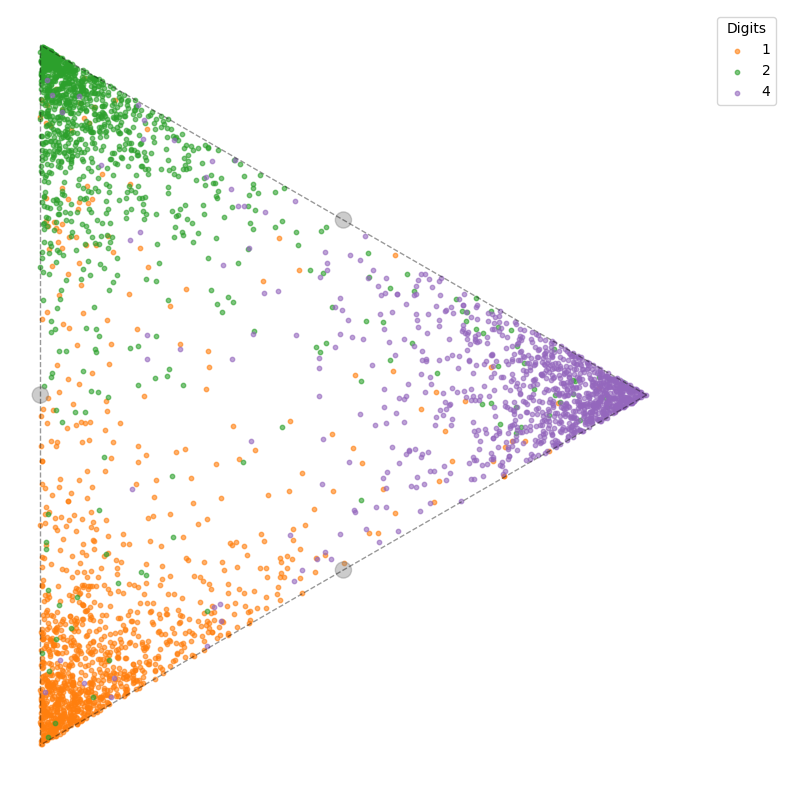

In [84]:
from plots.simplex import plot_mnist_simplex
import numpy as np
import torch
# Assuming test_loader, model, and device are defined

latents = []
labels = []

for x, y in test_loader:
    x = x.to(device)
    with torch.no_grad():
        # FIX: Model returns (recon_logits, lam, z) for the CCVAE
        # The return values are now unpacked correctly.
        recon_logits, lam, z = model(x) 
        
    # We save the CC latent sample (z) and the true labels (y)
    latents.append(z.cpu().numpy())
    labels.append(y.numpy())

latent_matrix = np.vstack(latents)
labels = np.hstack(labels)

# Assuming latent_dim (K) is correctly set to 3 or 4
plot_mnist_simplex(latent_matrix, labels, latent_dim)